# RQ3 Workload Characterization and Clustering

This notebook evaluates whether the Azure VM hourly workload sample can be grouped into four to six interpretable workload archetypes using VM-level time-series features.

**Research question:** Can Azure VMs be clustered into four to six interpretable workload archetypes using time-series features, and are these archetypes stable across utilization-intensity regimes?

The notebook is structured to produce visible output at every step: dataset checks, feature summaries, clustering metrics, selected model outputs, cluster profiles, utilization-regime stability, plots, and saved report artifacts.

## 1. Setup

The notebook uses only common Python packages: pandas, numpy, matplotlib, and scikit-learn. It does not require `tsfresh`, so the notebook remains portable and ready to run in a standard Jupyter environment.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.decomposition import PCA

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "../data/processed/hourly_n2000.parquet"
OUTPUT_DIR = "../data/reports/rq3_workload_clustering"

if not os.path.exists(DATA_PATH):
    alt_path = "data/processed/hourly_n2000.parquet"
    if os.path.exists(alt_path):
        DATA_PATH = alt_path

if not os.path.exists(OUTPUT_DIR):
    OUTPUT_DIR = "data/reports/rq3_workload_clustering"

os.makedirs(OUTPUT_DIR, exist_ok=True)

CPU_MEAN = "avg_cpu_mean"
CPU_MAX = "avg_cpu_max"
CPU_MIN = "avg_cpu_min"
CPU_STD = "avg_cpu_std"

print("DATA_PATH:", DATA_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

DATA_PATH: ../data/processed/hourly_n2000.parquet
OUTPUT_DIR: data/reports/rq3_workload_clustering


## 2. Load and Validate the Hourly Dataset

The unit of analysis in the raw modelling data is a VM-hour. For clustering, the notebook converts each VM's 720-hour series into one VM-level feature row.

In [2]:
def load_hourly_data(path=DATA_PATH):
    df = pd.read_parquet(path)
    df = df.sort_values(["vm_id", "hour_index"]).reset_index(drop=True)

    required_cols = [
        "vm_id", "hour_index", CPU_MEAN, CPU_MAX, CPU_MIN, CPU_STD,
        "hour_of_day", "day_index", "day_of_cycle"
    ]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    for col in [CPU_MEAN, CPU_MAX, CPU_MIN, CPU_STD]:
        df[col] = df[col].astype("float64")

    duplicate_count = df.duplicated(["vm_id", "hour_index"]).sum()
    if duplicate_count > 0:
        raise ValueError(f"Duplicate VM-hour rows found: {duplicate_count}")

    rows_per_vm = df.groupby("vm_id")["hour_index"].nunique()
    print("Shape:", df.shape)
    print("Unique VMs:", df["vm_id"].nunique())
    print("Unique hours:", df["hour_index"].nunique())
    print("Rows per VM summary:")
    display(rows_per_vm.describe().to_frame("hours_per_vm"))
    print("Missing values in required columns:")
    display(df[required_cols].isna().sum().to_frame("missing_count"))
    return df

hourly_df = load_hourly_data(DATA_PATH)
hourly_df.head()

Shape: (1440000, 10)
Unique VMs: 2000
Unique hours: 720
Rows per VM summary:


,hours_per_vm
count,2000.0
mean,720.0
std,0.0
min,720.0
25%,720.0
50%,720.0
75%,720.0
max,720.0


Missing values in required columns:


,missing_count
vm_id,0
hour_index,0
avg_cpu_mean,0
avg_cpu_max,0
avg_cpu_min,0
avg_cpu_std,0
hour_of_day,0
day_index,0
day_of_cycle,0


,vm_id,hour_index,avg_cpu_mean,avg_cpu_min,avg_cpu_max,avg_cpu_std,readings_count,hour_of_day,day_index,day_of_cycle
0,0,0,1.467899,1.281514,1.953717,0.199937,12,0,0,0
1,0,1,1.555141,1.382086,2.036626,0.167614,12,1,0,0
2,0,2,1.683001,1.511600,2.219195,0.220013,12,2,0,0
3,0,3,1.752279,1.615813,2.279033,0.176076,12,3,0,0
4,0,4,1.926054,1.774914,2.230747,0.127170,12,4,0,0


## 3. Build VM-Level Time-Series Features

The clustering model should not use one row per hour. Instead, it needs one compact behavioral signature per VM. The feature set captures utilization level, volatility, burstiness, trend, seasonality, and idle behavior.

The features are intentionally transparent so the resulting clusters can be explained in the report.

In [3]:
def safe_autocorr(values, lag):
    values = np.asarray(values, dtype=float)
    if len(values) <= lag:
        return 0.0
    x = values[:-lag]
    y = values[lag:]
    if np.nanstd(x) == 0 or np.nanstd(y) == 0:
        return 0.0
    return float(np.corrcoef(x, y)[0, 1])


def slope_per_hour(values):
    values = np.asarray(values, dtype=float)
    if len(values) < 2:
        return 0.0
    x = np.arange(len(values), dtype=float)
    try:
        return float(np.polyfit(x, values, 1)[0])
    except Exception:
        return 0.0


def entropy_10bin(values):
    values = np.asarray(values, dtype=float)
    hist, _ = np.histogram(values, bins=10, range=(0, 100), density=False)
    p = hist / max(hist.sum(), 1)
    p = p[p > 0]
    return float(-(p * np.log2(p)).sum()) if len(p) else 0.0


def build_vm_feature_table(df):
    rows = []
    for vm_id, g in df.sort_values(["vm_id", "hour_index"]).groupby("vm_id"):
        mean_cpu = g[CPU_MEAN].to_numpy(dtype=float)
        max_cpu = g[CPU_MAX].to_numpy(dtype=float)
        std_cpu = g[CPU_STD].to_numpy(dtype=float)

        q05, q25, q50, q75, q95 = np.percentile(mean_cpu, [5, 25, 50, 75, 95])
        max_q95 = np.percentile(max_cpu, 95)
        cpu_mean = float(np.mean(mean_cpu))
        cpu_std = float(np.std(mean_cpu))

        hourly_profile = g.groupby("hour_of_day")[CPU_MEAN].mean()
        cycle_profile = g.groupby("day_of_cycle")[CPU_MEAN].mean()

        rows.append({
            "vm_id": int(vm_id),
            "mean_cpu": cpu_mean,
            "median_cpu": float(q50),
            "std_cpu": cpu_std,
            "min_cpu": float(np.min(mean_cpu)),
            "max_cpu": float(np.max(mean_cpu)),
            "p05_cpu": float(q05),
            "p25_cpu": float(q25),
            "p75_cpu": float(q75),
            "p95_cpu_mean": float(q95),
            "p95_cpu_max": float(max_q95),
            "iqr_cpu": float(q75 - q25),
            "range_cpu": float(np.max(mean_cpu) - np.min(mean_cpu)),
            "cv_cpu": float(cpu_std / (cpu_mean + 1e-6)),
            "burstiness_index": float((q95 - q50) / (q50 + 1e-6)),
            "peak_to_mean_ratio": float(np.max(mean_cpu) / (cpu_mean + 1e-6)),
            "idle_fraction_lt_5": float(np.mean(mean_cpu < 5)),
            "low_fraction_lt_20": float(np.mean(mean_cpu < 20)),
            "high_fraction_gt_60": float(np.mean(mean_cpu > 60)),
            "very_high_fraction_gt_80": float(np.mean(mean_cpu > 80)),
            "mean_hourly_std": float(np.mean(std_cpu)),
            "max_hourly_std": float(np.max(std_cpu)),
            "autocorr_lag1": safe_autocorr(mean_cpu, 1),
            "autocorr_lag24": safe_autocorr(mean_cpu, 24),
            "trend_slope": slope_per_hour(mean_cpu),
            "entropy_10bin": entropy_10bin(mean_cpu),
            "hourly_profile_range": float(hourly_profile.max() - hourly_profile.min()) if len(hourly_profile) else 0.0,
            "cycle_profile_range": float(cycle_profile.max() - cycle_profile.min()) if len(cycle_profile) else 0.0,
            "complete_hours": int(len(g))
        })
    return pd.DataFrame(rows)

vm_features = build_vm_feature_table(hourly_df)
print("VM feature table shape:", vm_features.shape)
display(vm_features.head())
display(vm_features.describe().T.round(3))

VM feature table shape: (2000, 29)


,vm_id,mean_cpu,median_cpu,std_cpu,min_cpu,max_cpu,p05_cpu,p25_cpu,p75_cpu,p95_cpu_mean,...,very_high_fraction_gt_80,mean_hourly_std,max_hourly_std,autocorr_lag1,autocorr_lag24,trend_slope,entropy_10bin,hourly_profile_range,cycle_profile_range,complete_hours
0,0,1.279185,0.949102,0.928344,0.464270,10.078196,0.491849,0.540444,1.792533,2.944079,...,0.0,0.156047,13.907044,0.846691,0.707958,-0.002357,0.015185,0.755245,0.420120,720
1,1,4.758062,4.622718,1.479756,3.408491,28.775236,3.655753,4.338486,4.822868,5.482380,...,0.0,1.404490,22.973360,0.068753,0.039996,0.000898,0.153456,1.047591,0.419356,720
2,2,2.646828,2.231540,2.087692,1.923879,45.377884,2.010030,2.076946,2.914989,3.432912,...,0.0,0.599331,38.059513,0.296745,0.094739,0.002531,0.042770,1.464204,0.762819,720
3,3,0.417827,0.402262,0.081167,0.279764,1.256462,0.335106,0.370994,0.441547,0.543828,...,0.0,0.215191,1.307328,0.229491,0.111479,0.000034,-0.000000,0.097732,0.023004,720
4,4,41.188540,41.084167,0.888386,39.935921,50.537823,40.587612,40.858685,41.288342,41.506249,...,0.0,0.687072,23.107286,0.053965,0.025639,-0.000700,0.030368,0.579532,0.153917,720


,count,mean,std,min,25%,50%,75%,max
vm_id,2000.0,999.500,577.495,0.000,499.750,999.500,1499.250,1999.000
mean_cpu,2000.0,6.734,10.916,0.003,1.805,3.923,6.903,98.751
median_cpu,2000.0,6.270,11.170,0.003,1.607,3.495,6.320,98.962
std_cpu,2000.0,2.564,4.014,0.000,0.392,1.171,3.015,36.020
min_cpu,2000.0,3.998,7.485,0.003,1.068,2.375,4.462,96.692
max_cpu,2000.0,31.348,27.683,0.004,7.109,23.294,49.897,99.584
p05_cpu,2000.0,4.679,8.949,0.003,1.203,2.758,5.031,98.731
p25_cpu,2000.0,5.470,10.202,0.003,1.386,3.093,5.830,98.896
p75_cpu,2000.0,7.461,12.451,0.003,1.805,4.061,7.237,99.015
p95_cpu_mean,2000.0,10.257,15.635,0.004,2.507,5.084,9.401,99.382


## 4. Prepare the Feature Matrix

The clustering algorithms use standardized numeric features. The `vm_id` column is retained separately as an identifier and is not used as a model feature.

In [4]:
feature_cols = [c for c in vm_features.columns if c not in ["vm_id", "complete_hours"]]
feature_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(vm_features[c])]

X = vm_features[feature_cols].replace([np.inf, -np.inf], np.nan).copy()
medians = X.median(numeric_only=True)
X = X.fillna(medians).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Number of clustering features:", len(feature_cols))
print("Feature list:")
for col in feature_cols:
    print("-", col)

print("Scaled matrix shape:", X_scaled.shape)

Number of clustering features: 27
Feature list:
- mean_cpu
- median_cpu
- std_cpu
- min_cpu
- max_cpu
- p05_cpu
- p25_cpu
- p75_cpu
- p95_cpu_mean
- p95_cpu_max
- iqr_cpu
- range_cpu
- cv_cpu
- burstiness_index
- peak_to_mean_ratio
- idle_fraction_lt_5
- low_fraction_lt_20
- high_fraction_gt_60
- very_high_fraction_gt_80
- mean_hourly_std
- max_hourly_std
- autocorr_lag1
- autocorr_lag24
- trend_slope
- entropy_10bin
- hourly_profile_range
- cycle_profile_range
Scaled matrix shape: (2000, 27)


## 5. Evaluate Candidate Cluster Counts

RQ3 expects four to six interpretable archetypes. K-Means is evaluated for `k = 4, 5, 6`. The notebook reports inertia and silhouette score for each candidate.

,k,inertia,silhouette
0,4,26355.1350,0.2942
1,5,24047.2684,0.3027
2,6,22235.8996,0.2727


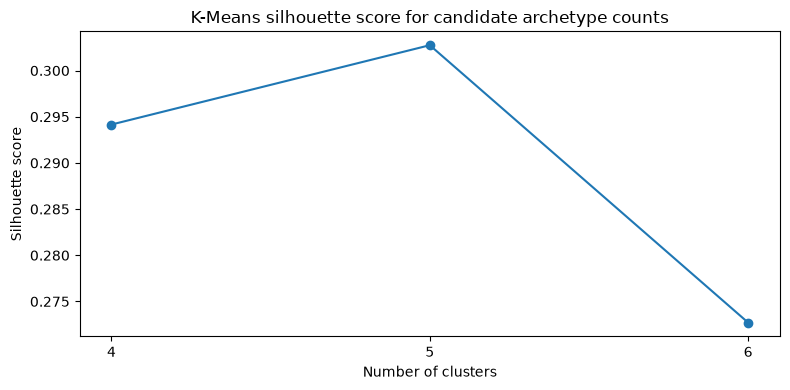

Selected k based on highest silhouette: 5


In [5]:
k_results = []
models = {}

for k in [4, 5, 6]:
    model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30)
    labels = model.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    k_results.append({"k": k, "inertia": model.inertia_, "silhouette": sil})
    models[k] = model

k_results_df = pd.DataFrame(k_results)
display(k_results_df.round(4))

plt.figure(figsize=(8, 4))
plt.plot(k_results_df["k"], k_results_df["silhouette"], marker="o")
plt.xticks([4, 5, 6])
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.title("K-Means silhouette score for candidate archetype counts")
plt.tight_layout()
plt.show()

selected_k = int(k_results_df.sort_values(["silhouette", "k"], ascending=[False, True]).iloc[0]["k"])
print("Selected k based on highest silhouette:", selected_k)

## 6. Fit the Final K-Means Model and Assign Archetypes

The selected K-Means model is applied to all VMs. Cluster IDs are then translated into readable archetype names using cluster profile statistics.

In [6]:
final_kmeans = models[selected_k]
vm_features["cluster"] = final_kmeans.predict(X_scaled)

profile_cols = [
    "mean_cpu", "p95_cpu_mean", "p95_cpu_max", "std_cpu", "burstiness_index",
    "idle_fraction_lt_5", "high_fraction_gt_60", "autocorr_lag24", "trend_slope",
    "hourly_profile_range", "cycle_profile_range"
]
cluster_profile = vm_features.groupby("cluster")[profile_cols].mean().round(3)
cluster_counts = vm_features["cluster"].value_counts().sort_index().rename("vm_count")
cluster_summary = cluster_profile.join(cluster_counts)
cluster_summary["vm_percent"] = (cluster_summary["vm_count"] / len(vm_features) * 100).round(2)

display(cluster_summary)

# Label clusters with compact, report-friendly names based on profile characteristics.
def assign_archetype_names(profile):
    names = {}
    temp = profile.copy()
    for cluster_id, row in temp.iterrows():
        if row["idle_fraction_lt_5"] >= 0.70 and row["mean_cpu"] < 10:
            name = "Idle / very low utilization"
        elif row["high_fraction_gt_60"] >= 0.20 or row["p95_cpu_mean"] >= 60:
            name = "High utilization"
        elif row["burstiness_index"] >= temp["burstiness_index"].quantile(0.75) or row["std_cpu"] >= temp["std_cpu"].quantile(0.75):
            name = "Bursty / variable"
        elif row["autocorr_lag24"] >= temp["autocorr_lag24"].median() and row["hourly_profile_range"] >= temp["hourly_profile_range"].median():
            name = "Cyclical / scheduled"
        else:
            name = "Steady moderate"
        names[cluster_id] = name
    return names

archetype_map = assign_archetype_names(cluster_summary)
vm_features["archetype"] = vm_features["cluster"].map(archetype_map)

print("Archetype map:")
for k, v in archetype_map.items():
    print(f"Cluster {k}: {v}")

display(vm_features[["vm_id", "cluster", "archetype", "mean_cpu", "p95_cpu_mean", "p95_cpu_max", "burstiness_index"]].head(10))

,mean_cpu,p95_cpu_mean,p95_cpu_max,std_cpu,burstiness_index,idle_fraction_lt_5,high_fraction_gt_60,autocorr_lag24,trend_slope,hourly_profile_range,cycle_profile_range,vm_count,vm_percent
cluster,,,,,,,,,,,,,
0,3.341,4.240,9.040,0.675,0.675,0.781,0.000,0.296,0.000,0.801,0.318,1134,56.70
1,4.421,6.363,15.451,2.948,1.405,0.620,0.001,0.108,0.001,2.596,1.349,558,27.90
2,85.901,90.349,92.702,5.394,0.036,0.000,0.977,0.496,-0.001,3.901,2.498,20,1.00
3,16.782,30.614,41.793,7.184,3.037,0.163,0.004,0.588,-0.001,8.711,4.440,249,12.45
4,33.731,69.910,78.218,21.051,18.291,0.169,0.184,0.560,0.014,14.068,13.454,39,1.95


Archetype map:
Cluster 0: Idle / very low utilization
Cluster 1: Steady moderate
Cluster 2: High utilization
Cluster 3: Bursty / variable
Cluster 4: High utilization


,vm_id,cluster,archetype,mean_cpu,p95_cpu_mean,p95_cpu_max,burstiness_index
0,0,0,Idle / very low utilization,1.279185,2.944079,3.421977,2.101960
1,1,0,Idle / very low utilization,4.758062,5.482380,13.374448,0.185965
2,2,1,Steady moderate,2.646828,3.432912,7.234301,0.538360
3,3,0,Idle / very low utilization,0.417827,0.543828,1.824460,0.351921
4,4,3,Bursty / variable,41.188540,41.506249,41.896081,0.010274
5,5,1,Steady moderate,2.524283,2.776831,6.213028,0.172920
6,6,0,Idle / very low utilization,0.152483,0.165227,0.318007,0.117693
7,7,0,Idle / very low utilization,1.973698,3.562493,11.506262,2.111011
8,8,0,Idle / very low utilization,9.869394,11.707761,18.896181,0.214513
9,9,1,Steady moderate,1.274609,1.774346,7.922574,0.576030


## 7. Visualize the Clusters with PCA

PCA is used only for visualization. The clustering model itself uses the full standardized feature matrix.

PCA explained variance ratio: [0.4145 0.161 ]


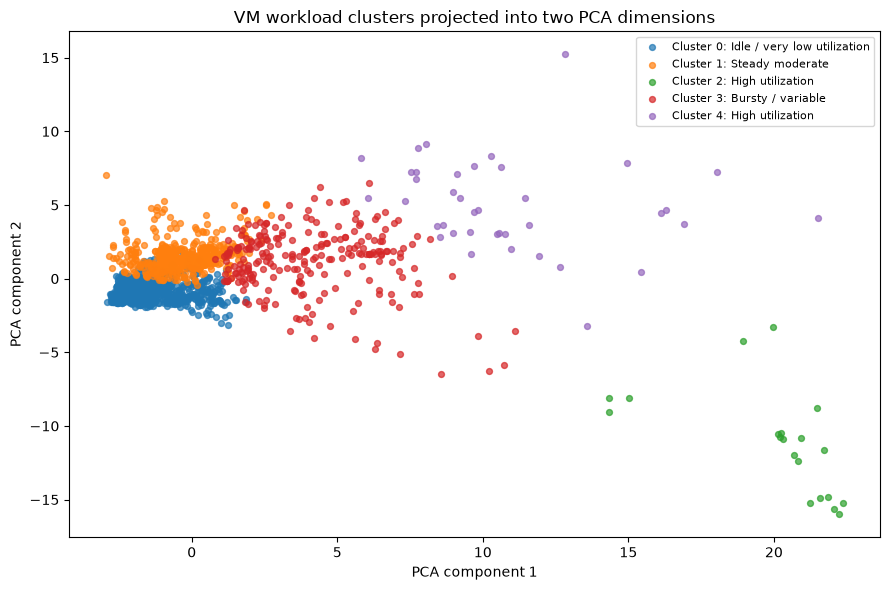

In [7]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
vm_features["pca1"] = coords[:, 0]
vm_features["pca2"] = coords[:, 1]

print("PCA explained variance ratio:", np.round(pca.explained_variance_ratio_, 4))

plt.figure(figsize=(9, 6))
for cluster_id, g in vm_features.groupby("cluster"):
    plt.scatter(g["pca1"], g["pca2"], s=18, alpha=0.7, label=f"Cluster {cluster_id}: {archetype_map[cluster_id]}")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("VM workload clusters projected into two PCA dimensions")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Compare with Alternative Clustering Methods

K-Means is the primary RQ3 model because it produces interpretable centroids. DBSCAN and Agglomerative clustering are included as secondary checks.

In [8]:
alt_rows = []

agg = AgglomerativeClustering(n_clusters=selected_k, linkage="ward")
agg_labels = agg.fit_predict(X_scaled)
alt_rows.append({
    "method": "Agglomerative Ward",
    "clusters_found": len(np.unique(agg_labels)),
    "silhouette": silhouette_score(X_scaled, agg_labels),
    "ARI_vs_KMeans": adjusted_rand_score(vm_features["cluster"], agg_labels)
})

for eps in [1.5, 2.0, 2.5, 3.0]:
    db = DBSCAN(eps=eps, min_samples=10)
    db_labels = db.fit_predict(X_scaled)
    non_noise = db_labels != -1
    clusters_found = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    if clusters_found >= 2 and non_noise.sum() > 10:
        sil = silhouette_score(X_scaled[non_noise], db_labels[non_noise])
    else:
        sil = np.nan
    alt_rows.append({
        "method": f"DBSCAN eps={eps}",
        "clusters_found": clusters_found,
        "noise_points": int((db_labels == -1).sum()),
        "silhouette": sil,
        "ARI_vs_KMeans": adjusted_rand_score(vm_features["cluster"], db_labels)
    })

alt_results_df = pd.DataFrame(alt_rows)
display(alt_results_df.round(4))

,method,clusters_found,silhouette,ARI_vs_KMeans,noise_points
0,Agglomerative Ward,5,0.2769,0.7815,NaN
1,DBSCAN eps=1.5,4,0.3673,0.3324,473.0
2,DBSCAN eps=2.0,5,0.2896,0.3175,324.0
3,DBSCAN eps=2.5,2,0.5250,0.2689,240.0
4,DBSCAN eps=3.0,1,NaN,0.1588,145.0


## 9. Bootstrap Stability Using Adjusted Rand Index

To test whether the archetypes are stable, the notebook repeatedly samples VMs with replacement, refits K-Means on each sample, and compares overlapping VM labels with the original clustering using Adjusted Rand Index.

,count,mean,std,min,25%,50%,75%,max
bootstrap_run,30.0,15.5000,8.8034,1.0000,8.2500,15.5000,22.750,30.0000
unique_vm_count,30.0,1097.9667,11.6574,1068.0000,1094.2500,1098.5000,1104.750,1122.0000
ARI,30.0,0.8553,0.1087,0.6426,0.8575,0.8853,0.906,0.9911


,bootstrap_run,unique_vm_count,ARI
0,1,1097,0.863885
1,2,1082,0.891117
2,3,1107,0.887138
3,4,1108,0.893861
4,5,1068,0.990217


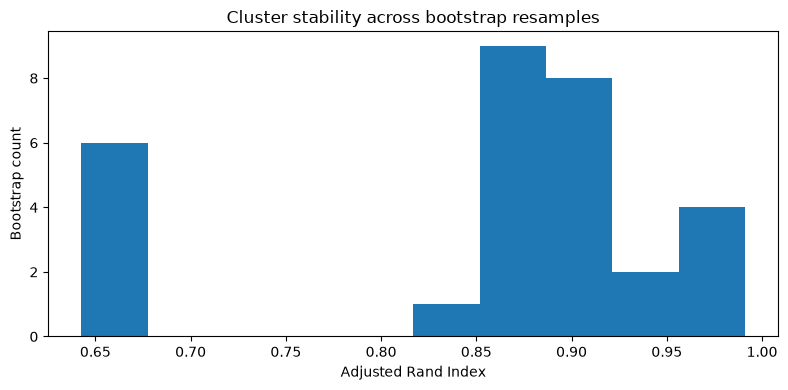

In [9]:
def bootstrap_cluster_stability(X_scaled, base_labels, n_boot=30, sample_frac=0.80, k=selected_k, random_state=RANDOM_STATE):
    rng = np.random.default_rng(random_state)
    n = X_scaled.shape[0]
    rows = []
    for i in range(n_boot):
        sample_idx = rng.choice(np.arange(n), size=int(n * sample_frac), replace=True)
        unique_idx = np.unique(sample_idx)
        model = KMeans(n_clusters=k, random_state=random_state + i + 1, n_init=20)
        boot_labels = model.fit_predict(X_scaled[unique_idx])
        ari = adjusted_rand_score(base_labels[unique_idx], boot_labels)
        rows.append({"bootstrap_run": i + 1, "unique_vm_count": len(unique_idx), "ARI": ari})
    return pd.DataFrame(rows)

stability_df = bootstrap_cluster_stability(X_scaled, vm_features["cluster"].to_numpy())
display(stability_df.describe().T.round(4))
display(stability_df.head())

plt.figure(figsize=(8, 4))
plt.hist(stability_df["ARI"], bins=10)
plt.xlabel("Adjusted Rand Index")
plt.ylabel("Bootstrap count")
plt.title("Cluster stability across bootstrap resamples")
plt.tight_layout()
plt.show()

## 10. Stability Across Utilization-Intensity Regimes

RQ3 also asks whether the archetypes remain stable across low, medium, and high utilization regimes. The notebook creates VM regimes from `mean_cpu` terciles and reports cluster composition within each regime.

Cluster counts by utilization regime:


archetype,Bursty / variable,High utilization,Idle / very low utilization,Steady moderate
utilization_regime,,,,
Low mean CPU,0,0,568,99
Medium mean CPU,3,0,367,296
High mean CPU,246,59,199,163


Cluster percentage by utilization regime:


archetype,Bursty / variable,High utilization,Idle / very low utilization,Steady moderate
utilization_regime,,,,
Low mean CPU,0.00,0.00,85.16,14.84
Medium mean CPU,0.45,0.00,55.11,44.44
High mean CPU,36.88,8.85,29.84,24.44


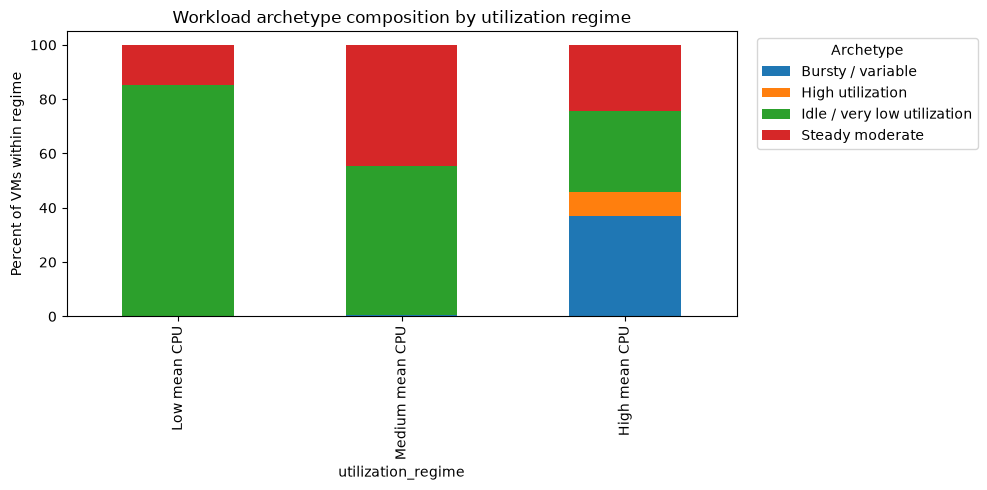

In [10]:
vm_features["utilization_regime"] = pd.qcut(
    vm_features["mean_cpu"].rank(method="first"),
    q=3,
    labels=["Low mean CPU", "Medium mean CPU", "High mean CPU"]
)

regime_cluster_counts = pd.crosstab(vm_features["utilization_regime"], vm_features["archetype"])
regime_cluster_pct = pd.crosstab(vm_features["utilization_regime"], vm_features["archetype"], normalize="index") * 100

print("Cluster counts by utilization regime:")
display(regime_cluster_counts)
print("Cluster percentage by utilization regime:")
display(regime_cluster_pct.round(2))

regime_cluster_pct.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.ylabel("Percent of VMs within regime")
plt.title("Workload archetype composition by utilization regime")
plt.legend(title="Archetype", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 11. Representative VM Time Series by Archetype

This plot shows one representative VM from each archetype. The representative VM is selected as the VM closest to the cluster centroid in standardized feature space.

,cluster,archetype,vm_id,distance_to_centroid
0,0,Idle / very low utilization,1669,0.745619
1,1,Steady moderate,883,0.944476
2,2,High utilization,1754,2.273931
3,3,Bursty / variable,1856,2.419434
4,4,High utilization,881,3.805801


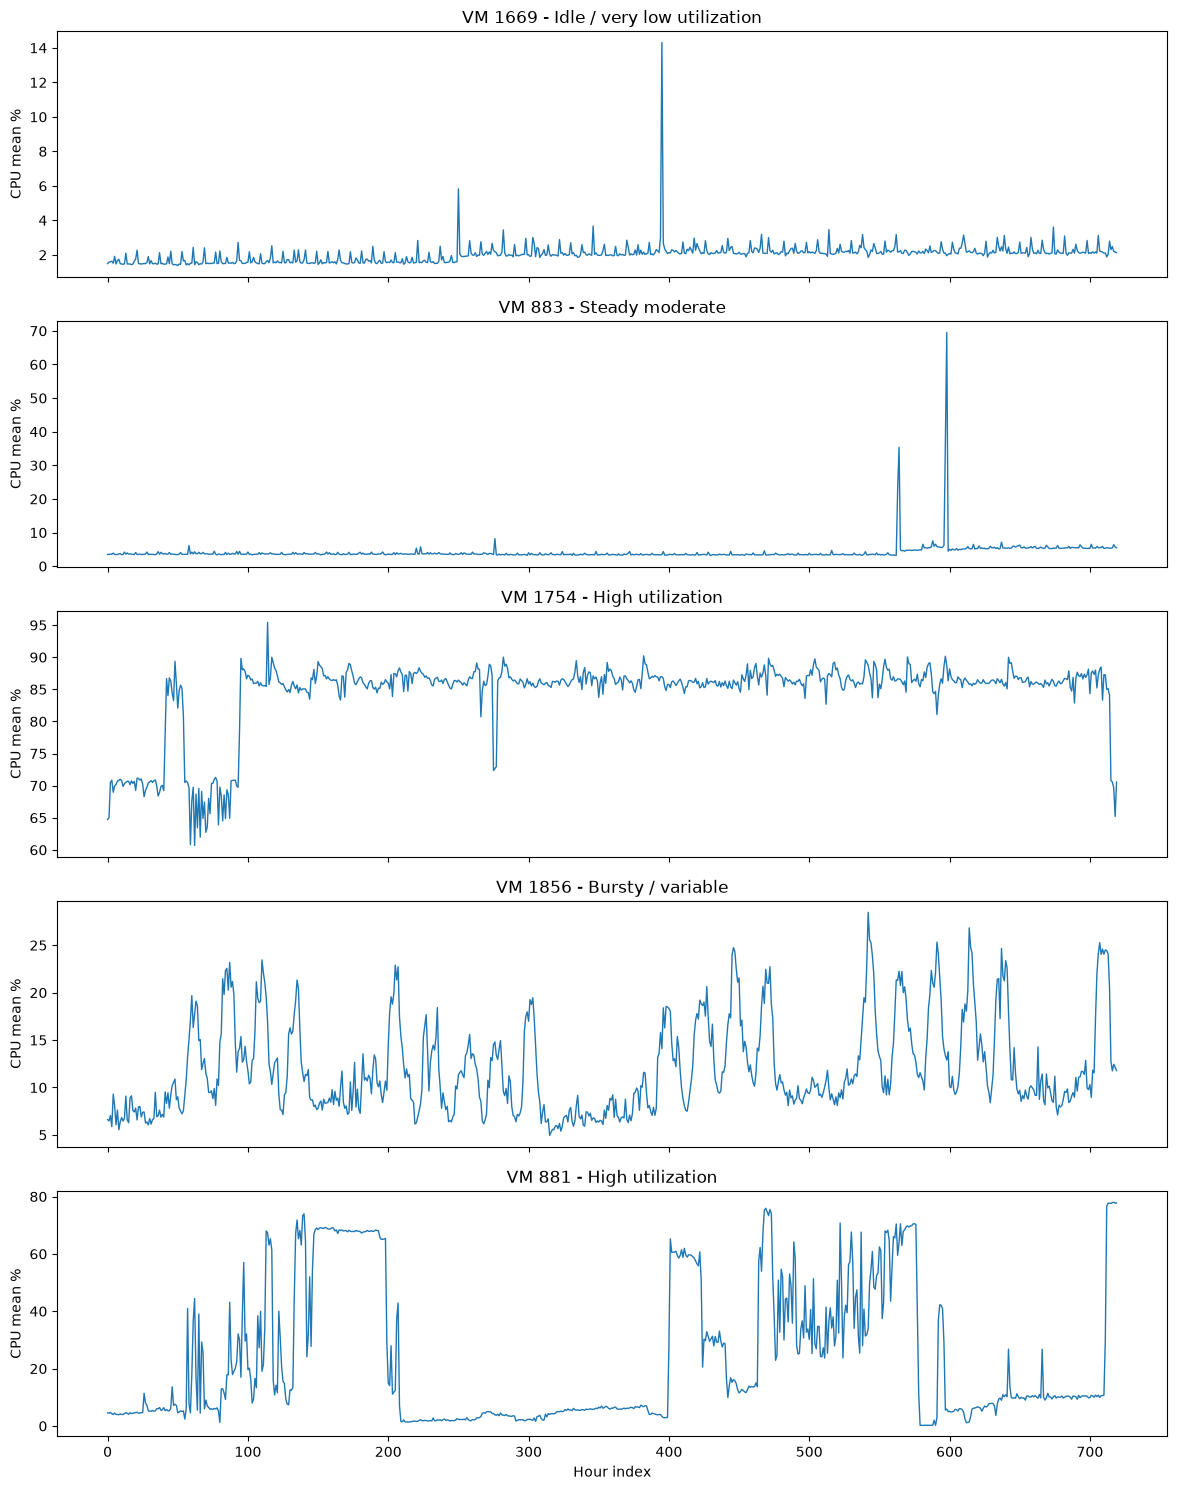

In [11]:
def representative_vm_ids(vm_features, X_scaled, model):
    reps = []
    labels = vm_features["cluster"].to_numpy()
    for cluster_id in sorted(np.unique(labels)):
        idx = np.where(labels == cluster_id)[0]
        center = model.cluster_centers_[cluster_id]
        distances = np.linalg.norm(X_scaled[idx] - center, axis=1)
        rep_idx = idx[np.argmin(distances)]
        reps.append({
            "cluster": cluster_id,
            "archetype": archetype_map[cluster_id],
            "vm_id": int(vm_features.iloc[rep_idx]["vm_id"]),
            "distance_to_centroid": float(distances.min())
        })
    return pd.DataFrame(reps)

representatives_df = representative_vm_ids(vm_features, X_scaled, final_kmeans)
display(representatives_df)

fig, axes = plt.subplots(len(representatives_df), 1, figsize=(12, 3 * len(representatives_df)), sharex=True)
if len(representatives_df) == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, representatives_df.iterrows()):
    vm_id = row["vm_id"]
    g = hourly_df[hourly_df["vm_id"] == vm_id].sort_values("hour_index")
    ax.plot(g["hour_index"], g[CPU_MEAN], linewidth=1)
    ax.set_title(f"VM {vm_id} - {row['archetype']}")
    ax.set_ylabel("CPU mean %")
ax.set_xlabel("Hour index")
plt.tight_layout()
plt.show()

## 12. Save RQ3 Outputs

The saved outputs are designed to support the final report tables and visuals.

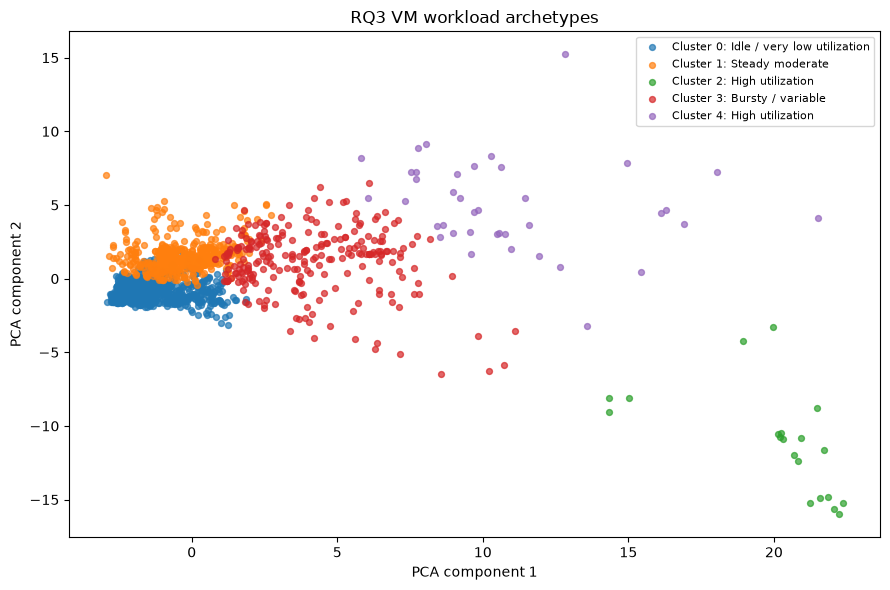

Saved RQ3 outputs to: data/reports/rq3_workload_clustering
PCA plot: data/reports/rq3_workload_clustering\rq3_pca_cluster_plot.png
Selected k: 5
Mean bootstrap ARI: 0.8553


In [12]:
vm_features.to_csv(os.path.join(OUTPUT_DIR, "rq3_vm_features_with_clusters.csv"), index=False)
cluster_summary.to_csv(os.path.join(OUTPUT_DIR, "rq3_cluster_summary.csv"))
k_results_df.to_csv(os.path.join(OUTPUT_DIR, "rq3_kmeans_k_selection.csv"), index=False)
stability_df.to_csv(os.path.join(OUTPUT_DIR, "rq3_bootstrap_stability.csv"), index=False)
regime_cluster_counts.to_csv(os.path.join(OUTPUT_DIR, "rq3_regime_cluster_counts.csv"))
regime_cluster_pct.to_csv(os.path.join(OUTPUT_DIR, "rq3_regime_cluster_percent.csv"))
representatives_df.to_csv(os.path.join(OUTPUT_DIR, "rq3_representative_vms.csv"), index=False)

# Save PCA plot as report artifact.
plt.figure(figsize=(9, 6))
for cluster_id, g in vm_features.groupby("cluster"):
    plt.scatter(g["pca1"], g["pca2"], s=18, alpha=0.7, label=f"Cluster {cluster_id}: {archetype_map[cluster_id]}")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")
plt.title("RQ3 VM workload archetypes")
plt.legend(fontsize=8)
plt.tight_layout()
pca_plot_path = os.path.join(OUTPUT_DIR, "rq3_pca_cluster_plot.png")
plt.savefig(pca_plot_path, dpi=150)
plt.show()

print("Saved RQ3 outputs to:", OUTPUT_DIR)
print("PCA plot:", pca_plot_path)
print("Selected k:", selected_k)
print("Mean bootstrap ARI:", round(stability_df["ARI"].mean(), 4))

## 13. Saving the model for Streamlite dashboard

In [17]:
import joblib
import os

os.makedirs("saved_models", exist_ok=True)

# Save scaler
joblib.dump(
    scaler,
    "saved_models/rq3_scaler.pkl"
)

# Save K=5 model
joblib.dump(
    models[5],
    "saved_models/rq3_kmeans_model.pkl"
)

print("RQ3 model saved.")

RQ3 model saved.


#### Create cluster labels

In [15]:
kmeans_model = models[5]

vm_features["cluster"] = kmeans_model.labels_

vm_features[
    ["vm_id", "cluster"]
].to_csv(
    "saved_models/vm_cluster_labels.csv",
    index=False
)

print("VM cluster labels saved.")

VM cluster labels saved.


#### saving the cluster centroids for dashboard interpretation

In [18]:
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(
        kmeans_model.cluster_centers_
    ),
    columns=feature_cols
)

cluster_centers["cluster"] = range(5)

cluster_centers.to_csv(
    "saved_models/cluster_profiles.csv",
    index=False
)

print("Cluster profiles saved.")

Cluster profiles saved.
